# 025 — Efficiency Analysis (rounds-to-consensus)

Efficiency = **mean_rounds**, the average number of rounds a task-config cell takes to
reach consensus. Mirrors the accuracy analysis (nb 023/024) on the same
35 tasks × 2 datasets × 2 topologies × 3 W = **420** task-config cells.

**Direction convention: fewer rounds = more efficient.** Rank 1 = fastest.

Round ceiling T=15 → `mean_rounds` is right-censored; ceiling-hit fractions are printed
so slow cells (esp. HiddenBench) are read as *lower bounds*.

In [1]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

BASE      = Path('..') / 'results' / 'mas' / 'final_dataset'
W_VALUES  = [1, 2, 5]
TOPOS     = ['fc', 'star']
DATASETS  = ['gpqa', 'hiddenbench']
W_COLORS  = {1: '#4C72B0', 2: '#DD8452', 5: '#55A868'}
T_COLORS  = {'fc': '#2c7bb6', 'star': '#d7191c'}
DS_LABELS = {'gpqa': 'GPQA', 'hiddenbench': 'HiddenBench'}
T_LABELS  = {'fc': 'FC', 'star': 'Star'}
CONFIG_ORDER  = [f'{t}/W={w}' for t in TOPOS for w in W_VALUES]
CONFIG_COLORS = [T_COLORS['fc']] * 3 + [T_COLORS['star']] * 3
T_CEIL = 15

def sig_stars(p):
    return '***' if p < .001 else ('**' if p < .01 else ('*' if p < .05 else 'ns'))

In [2]:
def load_tasks():
    rows = []
    for f in sorted(BASE.glob('**/*.json')):
        d      = json.loads(f.read_text())
        reps   = d['repetitions']
        rounds = [len(r['trajectory']) - 1 for r in reps]
        rows.append({
            'W':           d['W'],
            'dataset':     d['dataset'],
            'topology':    d.get('topology_name', 'fc'),
            'qid':         d['question_id'],
            'accuracy':    float(np.mean([r['correct'] for r in reps])),
            'mean_rounds': float(np.mean(rounds)),
            'ceil_frac':   float(np.mean(np.array(rounds) >= T_CEIL)),
            'n_reps':      len(reps),
        })
    return pd.DataFrame(rows)

tasks_df = load_tasks()
tasks_df['config'] = tasks_df['topology'] + '/W=' + tasks_df['W'].astype(str)
print(f'Task records: {len(tasks_df):,}')
print()
print('Mean rounds-to-consensus per config:')
print(tasks_df.groupby(['dataset', 'topology', 'W'])['mean_rounds'].mean().round(3).to_string())
print()
print('Fraction of reps hitting round ceiling (T=15) — mean_rounds is a LOWER bound where high:')
print(tasks_df.groupby(['dataset', 'topology', 'W'])['ceil_frac'].mean().round(3).to_string())

Task records: 420

Mean rounds-to-consensus per config:
dataset      topology  W
gpqa         fc        1    4.000
                       2    3.950
                       5    4.190
             star      1    4.498
                       2    4.329
                       5    4.595
hiddenbench  fc        1    6.486
                       2    6.004
                       5    6.470
             star      1    7.784
                       2    7.147
                       5    7.220

Fraction of reps hitting round ceiling (T=15) — mean_rounds is a LOWER bound where high:
dataset      topology  W
gpqa         fc        1    0.004
                       2    0.003
                       5    0.010
             star      1    0.017
                       2    0.012
                       5    0.024
hiddenbench  fc        1    0.112
                       2    0.106
                       5    0.146
             star      1    0.164
                       2    0.170
                      

## 1. Variance decomposition — task identity vs config choice

eta² from a one-way decomposition: how much of the spread in `mean_rounds` is explained by
*which problem* vs *which config*. Same framing as the accuracy sensitivity analysis.

In [3]:
for ds in DATASETS:
    sub   = tasks_df[tasks_df['dataset'] == ds]
    y     = sub['mean_rounds'].values
    grand = y.mean()
    ss_tot = ((y - grand) ** 2).sum()

    def eta2(col):
        return sum(len(g) * (g['mean_rounds'].mean() - grand) ** 2
                   for _, g in sub.groupby(col)) / ss_tot

    e_task, e_cfg = eta2('qid'), eta2('config')
    print(f'{DS_LABELS[ds]:12s}  eta^2(task)={e_task:.3f}  eta^2(config)={e_cfg:.3f}  '
          f'ratio task/config={e_task / e_cfg:.1f}x  (residual={1 - e_task - e_cfg:.3f})')

GPQA          eta^2(task)=0.612  eta^2(config)=0.078  ratio task/config=7.8x  (residual=0.310)
HiddenBench   eta^2(task)=0.505  eta^2(config)=0.084  ratio task/config=6.0x  (residual=0.411)


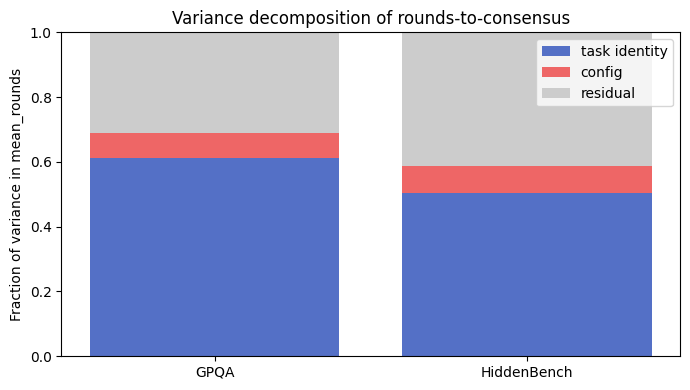

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
rows = []
for ds in DATASETS:
    sub   = tasks_df[tasks_df['dataset'] == ds]
    y     = sub['mean_rounds'].values
    grand = y.mean(); ss_tot = ((y - grand) ** 2).sum()
    def eta2(col):
        return sum(len(g) * (g['mean_rounds'].mean() - grand) ** 2
                   for _, g in sub.groupby(col)) / ss_tot
    rows.append((eta2('qid'), eta2('config')))
x = np.arange(len(DATASETS))
task_e = [r[0] for r in rows]; cfg_e = [r[1] for r in rows]
res_e  = [1 - t - c for t, c in rows]
ax.bar(x, task_e, label='task identity', color='#5470C6')
ax.bar(x, cfg_e, bottom=task_e, label='config', color='#EE6666')
ax.bar(x, res_e, bottom=[t + c for t, c in rows], label='residual', color='#cccccc')
ax.set_xticks(x); ax.set_xticklabels([DS_LABELS[d] for d in DATASETS])
ax.set_ylabel('Fraction of variance in mean_rounds'); ax.set_ylim(0, 1)
ax.legend(); ax.set_title('Variance decomposition of rounds-to-consensus')
plt.tight_layout(); plt.show()

## 2. Adjusted efficiency — deviation from per-task mean

Center each task at zero (`rounds_adj = mean_rounds − task_mean`), so task difficulty is
removed and only the config effect remains. **Negative = converges faster than the task
typically does.** t-test vs 0 across 35 tasks.

In [5]:
tasks_df['task_mean_rounds'] = tasks_df.groupby(['dataset', 'qid'])['mean_rounds'].transform('mean')
tasks_df['rounds_adj'] = tasks_df['mean_rounds'] - tasks_df['task_mean_rounds']

for ds in DATASETS:
    print(f'{DS_LABELS[ds]}')
    sub = tasks_df[tasks_df['dataset'] == ds]
    print(f'  {"config":10s}  {"mean_adj":>9s}  {"std":>7s}  {"t":>7s}  {"p":>8s}   sig')
    for c in CONFIG_ORDER:
        vals = sub[sub['config'] == c]['rounds_adj'].dropna().values
        t, p = sp_stats.ttest_1samp(vals, 0.0)
        print(f'  {c:10s}  {vals.mean():>9.3f}  {vals.std(ddof=1):>7.3f}  '
              f'{t:>7.2f}  {p:>8.4f}   {sig_stars(p)}')
    print()

GPQA
  config       mean_adj      std        t         p   sig
  fc/W=1         -0.260    0.488    -3.16    0.0033   **
  fc/W=2         -0.310    0.403    -4.55    0.0001   ***
  fc/W=5         -0.070    0.458    -0.90    0.3721   ns
  star/W=1        0.238    0.516     2.72    0.0101   *
  star/W=2        0.068    0.445     0.90    0.3719   ns
  star/W=5        0.335    0.569     3.48    0.0014   **

HiddenBench
  config       mean_adj      std        t         p   sig
  fc/W=1         -0.366    1.385    -1.56    0.1272   ns
  fc/W=2         -0.848    1.228    -4.09    0.0003   ***
  fc/W=5         -0.381    1.328    -1.70    0.0986   ns
  star/W=1        0.932    1.553     3.55    0.0012   **
  star/W=2        0.295    1.250     1.40    0.1718   ns
  star/W=5        0.368    1.167     1.87    0.0705   ns



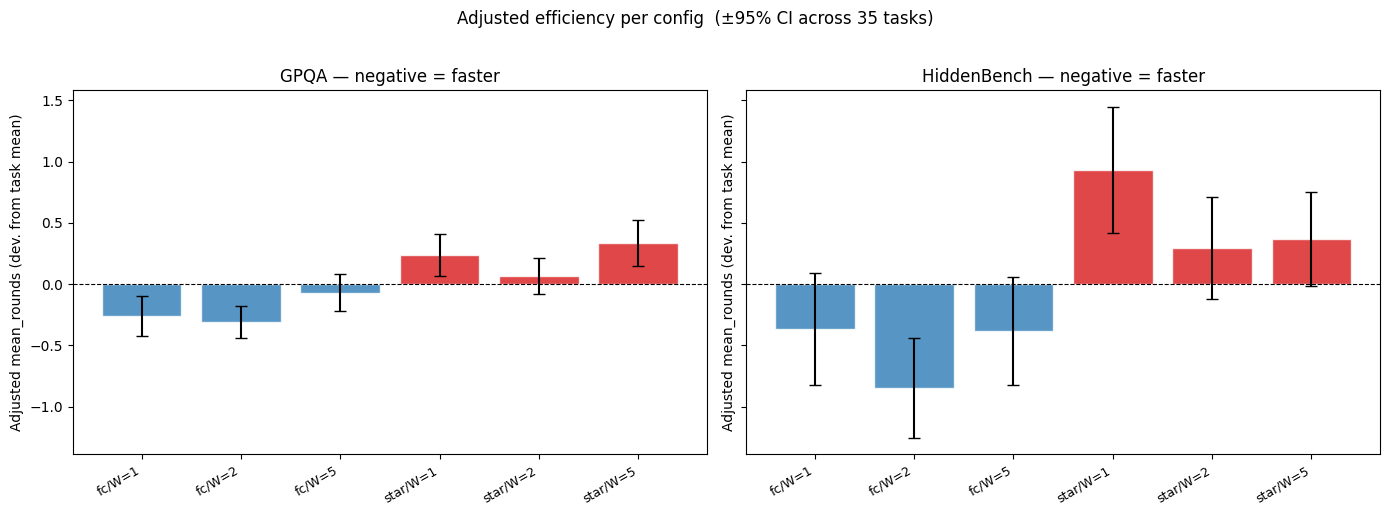

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, ds in zip(axes, DATASETS):
    sub   = tasks_df[tasks_df['dataset'] == ds]
    means = [sub[sub['config'] == c]['rounds_adj'].mean() for c in CONFIG_ORDER]
    sems  = [sub[sub['config'] == c]['rounds_adj'].sem()  for c in CONFIG_ORDER]
    ax.bar(range(len(CONFIG_ORDER)), means, yerr=[1.96 * s for s in sems],
           color=CONFIG_COLORS, alpha=0.8, capsize=4, edgecolor='white')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xticks(range(len(CONFIG_ORDER)))
    ax.set_xticklabels(CONFIG_ORDER, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Adjusted mean_rounds (dev. from task mean)')
    ax.set_title(f'{DS_LABELS[ds]} — negative = faster')
fig.suptitle('Adjusted efficiency per config  (±95% CI across 35 tasks)', y=1.02)
plt.tight_layout(); plt.show()

## 3. Memory axis (W) — Friedman + Borda + pairwise Wilcoxon

Per task, average `mean_rounds` across topologies, rank W=1/2/5 (rank 1 = fewest rounds).
Friedman for overall W effect; Borda points (rank1→2, rank2→1, rank3→0); pairwise Wilcoxon
signed-rank on matched tasks.

In [7]:
w_axis = (tasks_df.groupby(['dataset', 'qid', 'W'])['mean_rounds'].mean().reset_index())
for ds in DATASETS:
    print(f'{DS_LABELS[ds]}')
    sub = w_axis[w_axis['dataset'] == ds]
    piv = sub.pivot(index='qid', columns='W', values='mean_rounds')[W_VALUES].dropna()
    chi, p = sp_stats.friedmanchisquare(*[piv[w].values for w in W_VALUES])
    print(f'  Friedman chi2={chi:.3f}  p={p:.4f} {sig_stars(p)}  (n={len(piv)} tasks)')
    ranks = piv.rank(axis=1, method='average')          # rank 1 = fewest rounds
    borda = (len(W_VALUES) - ranks)
    print(f'  mean rounds      : ' + '  '.join(f'W={w}:{piv[w].mean():.3f}' for w in W_VALUES))
    print(f'  mean rank(1=fast): ' + '  '.join(f'W={w}:{ranks[w].mean():.3f}' for w in W_VALUES))
    print(f'  Borda points     : ' + '  '.join(f'W={w}:{borda[w].sum():.0f}' for w in W_VALUES))
    print('  pairwise Wilcoxon signed-rank:')
    for a, b in combinations(W_VALUES, 2):
        st, pw = sp_stats.wilcoxon(piv[a].values, piv[b].values, alternative='two-sided')
        print(f'    W={a}({piv[a].mean():.3f}) vs W={b}({piv[b].mean():.3f})  p={pw:.4f} {sig_stars(pw)}')
    print()

GPQA
  Friedman chi2=8.647  p=0.0133 *  (n=35 tasks)
  mean rounds      : W=1:4.249  W=2:4.140  W=5:4.393
  mean rank(1=fast): W=1:2.014  W=2:1.643  W=5:2.343
  Borda points     : W=1:34  W=2:48  W=5:23
  pairwise Wilcoxon signed-rank:
    W=1(4.249) vs W=2(4.140)  p=0.1281 ns
    W=1(4.249) vs W=5(4.393)  p=0.0619 ns
    W=2(4.140) vs W=5(4.393)  p=0.0016 **

HiddenBench
  Friedman chi2=7.554  p=0.0229 *  (n=35 tasks)
  mean rounds      : W=1:7.135  W=2:6.575  W=5:6.845
  mean rank(1=fast): W=1:2.286  W=2:1.643  W=5:2.071
  Borda points     : W=1:25  W=2:48  W=5:32
  pairwise Wilcoxon signed-rank:
    W=1(7.135) vs W=2(6.575)  p=0.0009 ***
    W=1(7.135) vs W=5(6.845)  p=0.1541 ns
    W=2(6.575) vs W=5(6.845)  p=0.0257 *



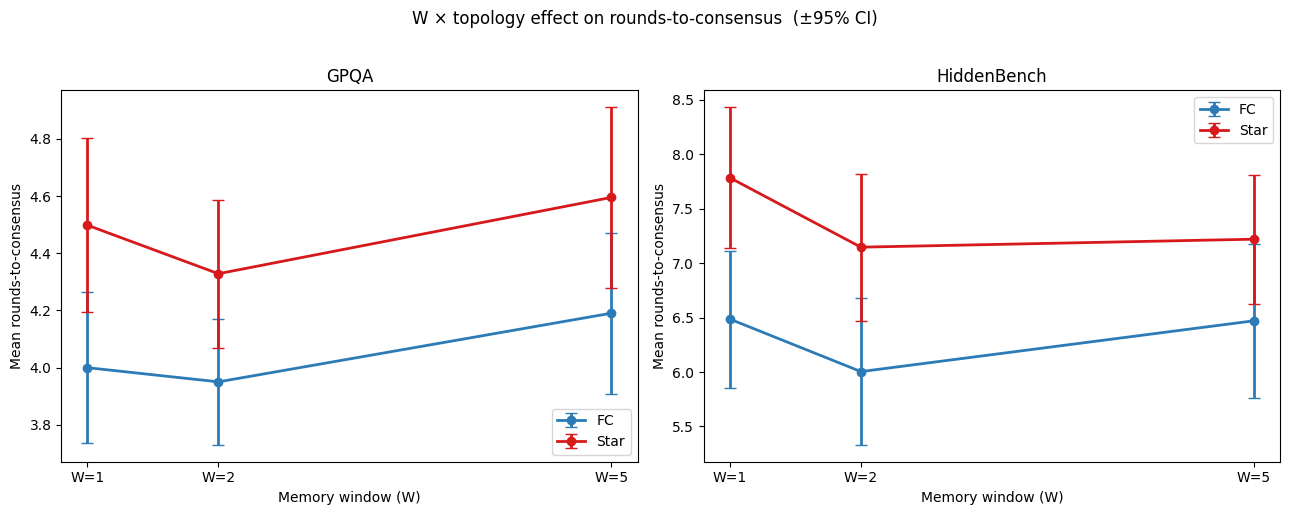

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, ds in zip(axes, DATASETS):
    sub = tasks_df[tasks_df['dataset'] == ds]
    for topo in TOPOS:
        t_sub = sub[sub['topology'] == topo]
        means = [t_sub[t_sub['W'] == w]['mean_rounds'].mean() for w in W_VALUES]
        sems  = [t_sub[t_sub['W'] == w]['mean_rounds'].sem()  for w in W_VALUES]
        ax.errorbar(W_VALUES, means, yerr=[1.96 * s for s in sems], marker='o',
                    linewidth=2, capsize=4, color=T_COLORS[topo], label=T_LABELS[topo])
    ax.set_xticks(W_VALUES); ax.set_xticklabels([f'W={w}' for w in W_VALUES])
    ax.set_xlabel('Memory window (W)'); ax.set_ylabel('Mean rounds-to-consensus')
    ax.set_title(f'{DS_LABELS[ds]}'); ax.legend()
fig.suptitle('W × topology effect on rounds-to-consensus  (±95% CI)', y=1.02)
plt.tight_layout(); plt.show()

## 4. Topology axis — FC vs Star (paired Wilcoxon)

Per task, average `mean_rounds` across W, pair FC vs Star. diff = FC − Star; negative ⇒ FC
faster.

In [9]:
t_axis = (tasks_df.groupby(['dataset', 'qid', 'topology'])['mean_rounds'].mean().reset_index())
for ds in DATASETS:
    sub  = t_axis[t_axis['dataset'] == ds]
    piv  = sub.pivot(index='qid', columns='topology', values='mean_rounds')[TOPOS].dropna()
    diff = piv['fc'] - piv['star']
    dz   = diff[diff != 0]
    st, pw = sp_stats.wilcoxon(dz, alternative='two-sided')
    print(f'{DS_LABELS[ds]:12s}  fc={piv["fc"].mean():.3f}  star={piv["star"].mean():.3f}  '
          f'mean diff(fc-star)={diff.mean():+.3f}  '
          f'fc_faster={int((diff < 0).sum())}  star_faster={int((diff > 0).sum())}  '
          f'p={pw:.4f} {sig_stars(pw)}')

GPQA          fc=4.047  star=4.474  mean diff(fc-star)=-0.427  fc_faster=28  star_faster=7  p=0.0006 ***
HiddenBench   fc=6.320  star=7.383  mean diff(fc-star)=-1.063  fc_faster=29  star_faster=6  p=0.0007 ***


## 5. Full 6-way ranking

Rank all 6 configs per task (1 = fewest rounds). Mean rank, most-common rank-1, and a 6×6
win matrix (`W[i,j]` = #tasks config *i* has fewer rounds than *j*).

In [10]:
tasks_df['rank6'] = (tasks_df.groupby(['dataset', 'qid'])['mean_rounds']
                     .rank(ascending=True, method='average'))
win_matrices = {}
for ds in DATASETS:
    print(f'\n{DS_LABELS[ds]}')
    sub = tasks_df[tasks_df['dataset'] == ds]
    nq  = sub['qid'].nunique()

    print('  Mean rank per config (1=fastest, 6=slowest):')
    mr = sub.groupby('config')['rank6'].mean().reindex(CONFIG_ORDER)
    for c in CONFIG_ORDER:
        print(f'    {c:10s}  {mr[c]:.3f}')

    print('  Most-common rank-1 (fastest) counts:')
    r1 = (sub[sub['rank6'] == 1].groupby('config').size()
          .reindex(CONFIG_ORDER).fillna(0).astype(int))
    for c in CONFIG_ORDER:
        print(f'    {c:10s}  {r1[c]:>3d}  ({r1[c] / nq:.2f})')

    piv = sub.pivot_table(index='qid', columns='config', values='mean_rounds')[CONFIG_ORDER]
    win = pd.DataFrame(0, index=CONFIG_ORDER, columns=CONFIG_ORDER)
    for i in CONFIG_ORDER:
        for j in CONFIG_ORDER:
            if i != j:
                win.loc[i, j] = int((piv[i] < piv[j]).sum())
    win_matrices[ds] = win
    print('  6x6 win matrix (row beats col = fewer rounds):')
    print(win.to_string())
    wr = win.sum(axis=1) / (5 * nq)
    print('  overall win rate:')
    for c in CONFIG_ORDER:
        print(f'    {c:10s}  {wr[c]:.3f}')


GPQA
  Mean rank per config (1=fastest, 6=slowest):
    fc/W=1      2.700
    fc/W=2      2.371
    fc/W=5      3.371
    star/W=1    4.129
    star/W=2    3.757
    star/W=5    4.671
  Most-common rank-1 (fastest) counts:
    fc/W=1        9  (0.26)
    fc/W=2       10  (0.29)
    fc/W=5        5  (0.14)
    star/W=1      0  (0.00)
    star/W=2      6  (0.17)
    star/W=5      1  (0.03)
  6x6 win matrix (row beats col = fewer rounds):
          fc/W=1  fc/W=2  fc/W=5  star/W=1  star/W=2  star/W=5
fc/W=1         0      17      22        24        22        28
fc/W=2        17       0      24        25        26        32
fc/W=5        12      10       0        22        21        25
star/W=1       9       7      13         0        14        20
star/W=2      13       8      14        21         0        21
star/W=5       6       3       8        15        12         0
  overall win rate:
    fc/W=1      0.646
    fc/W=2      0.709
    fc/W=5      0.514
    star/W=1    0.360
    star/W

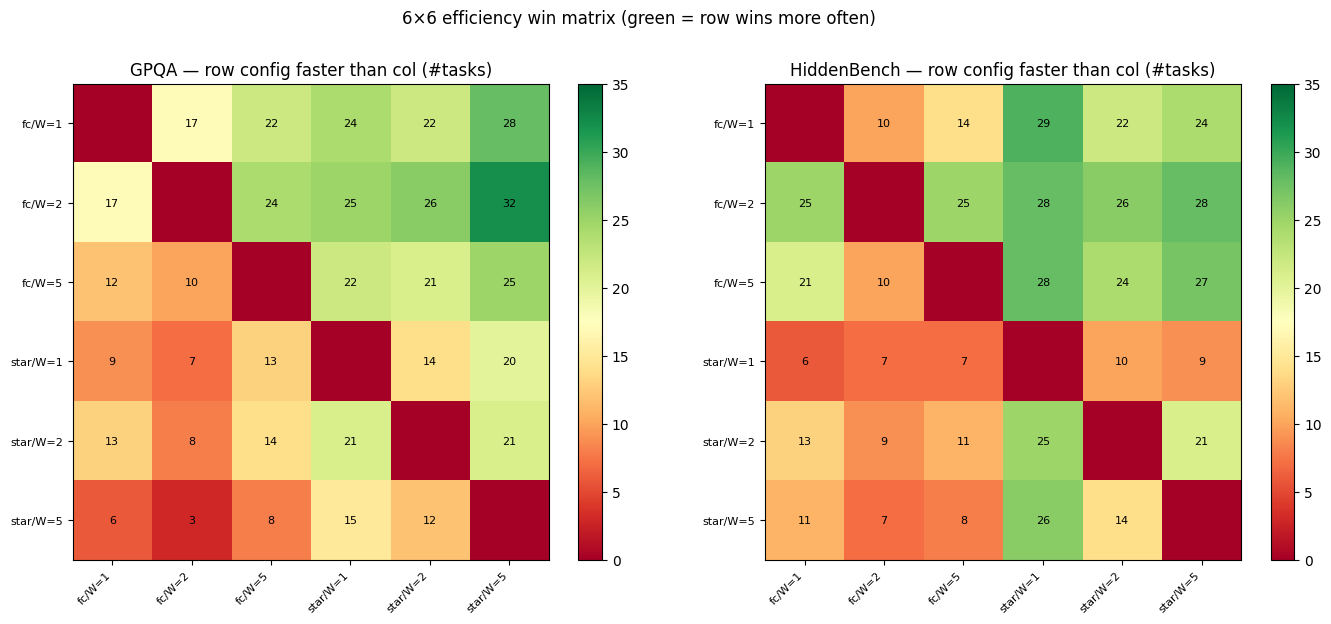

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, ds in zip(axes, DATASETS):
    win = win_matrices[ds]
    im = ax.imshow(win.values, cmap='RdYlGn', vmin=0, vmax=35)
    ax.set_xticks(range(6)); ax.set_xticklabels(CONFIG_ORDER, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(6)); ax.set_yticklabels(CONFIG_ORDER, fontsize=8)
    for i in range(6):
        for j in range(6):
            if i != j:
                ax.text(j, i, int(win.values[i, j]), ha='center', va='center', fontsize=8)
    ax.set_title(f'{DS_LABELS[ds]} — row config faster than col (#tasks)')
    plt.colorbar(im, ax=ax, fraction=0.045)
fig.suptitle('6×6 efficiency win matrix (green = row wins more often)', y=1.02)
plt.tight_layout(); plt.show()

## 6. Per-task distribution

Sorted bars of `mean_rounds` per task with min–max range across the 6 configs; top/bottom 5.

In [12]:
for ds in DATASETS:
    print(f'\n{DS_LABELS[ds]}  (sorted by mean rounds across configs)')
    sub = tasks_df[tasks_df['dataset'] == ds]
    agg = (sub.groupby('qid')['mean_rounds']
           .agg(mean='mean', lo='min', hi='max').reset_index().sort_values('mean'))
    agg['range'] = agg['hi'] - agg['lo']
    maxbar = agg['mean'].max()
    for _, r in agg.iterrows():
        bar = '#' * int(round(40 * r['mean'] / maxbar))
        print(f'    q{int(r.qid):>3d}  {r["mean"]:>5.2f}  [{r.lo:>4.2f}-{r.hi:>5.2f}] '
              f'rng={r["range"]:>4.2f}  {bar}')
    print('  TOP 5 slowest: '  + ', '.join(f'q{int(x)}={v:.2f}' for x, v in zip(agg.tail(5)['qid'], agg.tail(5)['mean'])))
    print('  BOTTOM 5 fastest: ' + ', '.join(f'q{int(x)}={v:.2f}' for x, v in zip(agg.head(5)['qid'], agg.head(5)['mean'])))


GPQA  (sorted by mean rounds across configs)
    q 50   2.59  [2.17- 2.87] rng=0.70  ###################
    q 26   2.73  [2.40- 3.30] rng=0.90  ####################
    q 90   3.47  [3.20- 3.77] rng=0.57  #########################
    q  3   3.52  [2.93- 4.00] rng=1.07  ##########################
    q136   3.57  [3.07- 4.03] rng=0.97  ##########################
    q 80   3.57  [2.93- 4.90] rng=1.97  ##########################
    q 33   3.58  [3.20- 4.30] rng=1.10  ##########################
    q157   3.59  [2.53- 4.37] rng=1.83  ##########################
    q146   3.64  [3.17- 4.10] rng=0.93  ###########################
    q  5   3.99  [3.47- 4.47] rng=1.00  #############################
    q182   4.04  [3.70- 4.73] rng=1.03  ##############################
    q149   4.12  [3.17- 5.33] rng=2.17  ##############################
    q 23   4.13  [3.83- 4.63] rng=0.80  ##############################
    q173   4.17  [3.30- 5.37] rng=2.07  ##############################
    q164  

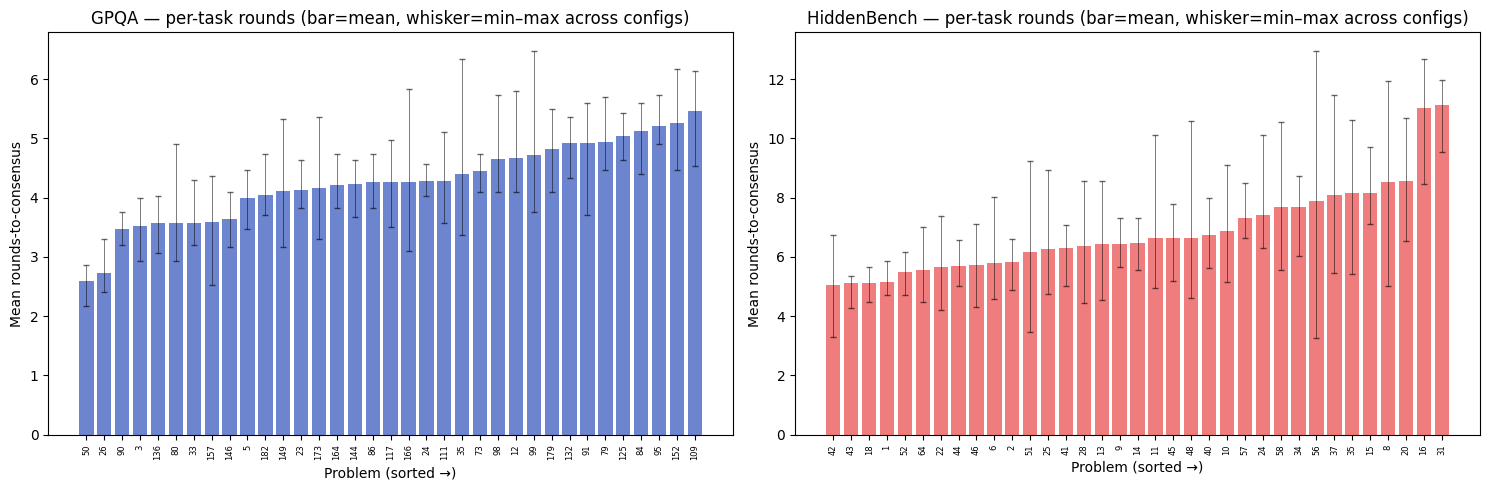

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, ds in zip(axes, DATASETS):
    sub = tasks_df[tasks_df['dataset'] == ds]
    agg = (sub.groupby('qid')['mean_rounds']
           .agg(mean='mean', lo='min', hi='max').reset_index().sort_values('mean'))
    x = np.arange(len(agg))
    ax.bar(x, agg['mean'], color='#5470C6' if ds == 'gpqa' else '#EE6666', alpha=0.85)
    ax.errorbar(x, agg['mean'],
                yerr=[agg['mean'] - agg['lo'], agg['hi'] - agg['mean']],
                fmt='none', ecolor='black', elinewidth=0.6, capsize=2, alpha=0.6)
    ax.set_xticks(x); ax.set_xticklabels(agg['qid'].astype(int), rotation=90, fontsize=6)
    ax.set_ylabel('Mean rounds-to-consensus'); ax.set_xlabel('Problem (sorted →)')
    ax.set_title(f'{DS_LABELS[ds]} — per-task rounds (bar=mean, whisker=min–max across configs)')
plt.tight_layout(); plt.show()

## 7. Accuracy vs efficiency correlation

Spearman ρ between `accuracy` and `mean_rounds`. Positive ⇒ more rounds ↔ higher accuracy
(deliberation helps); negative ⇒ hard problems drag out *and* are answered worse.

In [14]:
print('Per dataset (all 210 task-config cells):')
for ds in DATASETS:
    sub = tasks_df[tasks_df['dataset'] == ds]
    rho, p = sp_stats.spearmanr(sub['accuracy'], sub['mean_rounds'])
    print(f'  {DS_LABELS[ds]:12s}  rho={rho:+.3f}  p={p:.4f} {sig_stars(p)}  (n={len(sub)})')
print()
print('Per dataset x config (across 35 tasks):')
for ds in DATASETS:
    print(f'  {DS_LABELS[ds]}')
    sub = tasks_df[tasks_df['dataset'] == ds]
    for c in CONFIG_ORDER:
        s = sub[sub['config'] == c]
        rho, p = sp_stats.spearmanr(s['accuracy'], s['mean_rounds'])
        print(f'    {c:10s}  rho={rho:+.3f}  p={p:.4f} {sig_stars(p)}')

Per dataset (all 210 task-config cells):
  GPQA          rho=-0.261  p=0.0001 ***  (n=210)
  HiddenBench   rho=+0.148  p=0.0322 *  (n=210)

Per dataset x config (across 35 tasks):
  GPQA
    fc/W=1      rho=-0.536  p=0.0009 ***
    fc/W=2      rho=-0.381  p=0.0238 *
    fc/W=5      rho=-0.443  p=0.0078 **
    star/W=1    rho=-0.190  p=0.2754 ns
    star/W=2    rho=-0.080  p=0.6486 ns
    star/W=5    rho=-0.073  p=0.6759 ns
  HiddenBench
    fc/W=1      rho=+0.096  p=0.5825 ns
    fc/W=2      rho=+0.128  p=0.4637 ns
    fc/W=5      rho=+0.280  p=0.1036 ns
    star/W=1    rho=+0.364  p=0.0314 *
    star/W=2    rho=+0.168  p=0.3359 ns
    star/W=5    rho=+0.093  p=0.5933 ns


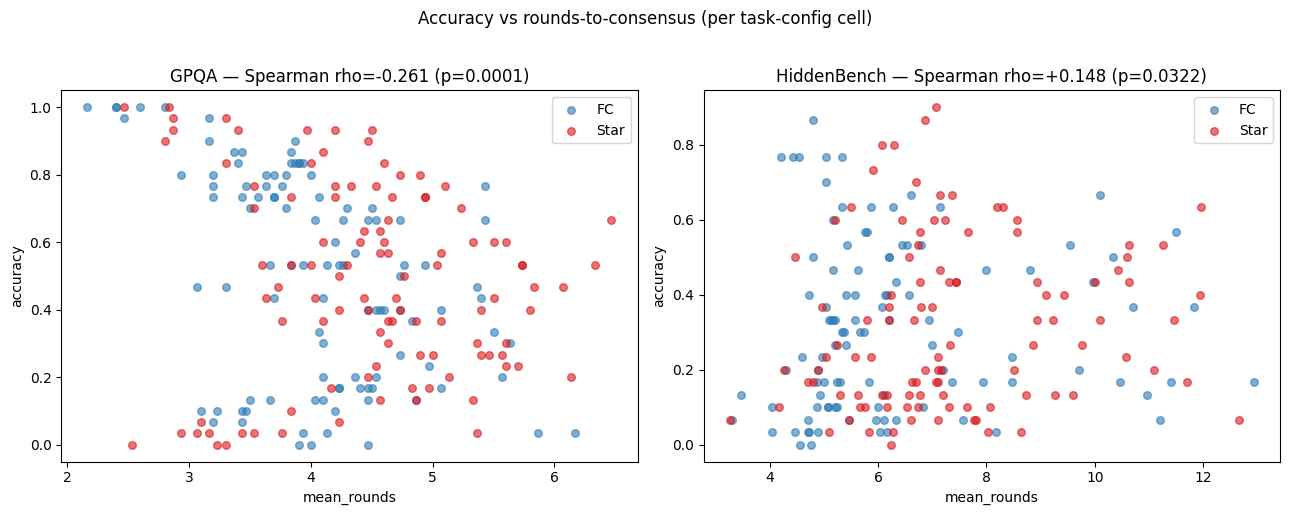

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, ds in zip(axes, DATASETS):
    sub = tasks_df[tasks_df['dataset'] == ds]
    for topo in TOPOS:
        t_sub = sub[sub['topology'] == topo]
        ax.scatter(t_sub['mean_rounds'], t_sub['accuracy'], alpha=0.6, s=30,
                   color=T_COLORS[topo], label=T_LABELS[topo])
    rho, p = sp_stats.spearmanr(sub['accuracy'], sub['mean_rounds'])
    ax.set_xlabel('mean_rounds'); ax.set_ylabel('accuracy')
    ax.set_title(f'{DS_LABELS[ds]} — Spearman rho={rho:+.3f} (p={p:.4f})')
    ax.legend()
fig.suptitle('Accuracy vs rounds-to-consensus (per task-config cell)', y=1.02)
plt.tight_layout(); plt.show()

## 8. Summary — consistent patterns vs noise

**Consistent across both datasets (robust):**
- **Task identity dominates.** eta²(task) ≈ 0.51–0.61 vs eta²(config) ≈ 0.08 → task/config
  ratio 6–8×. *Which problem* drives rounds far more than *which config*, exactly as for
  accuracy.
- **FC converges faster than Star.** Paired Wilcoxon p<0.001 both datasets; FC faster on
  28/35 (GPQA) and 29/35 (HiddenBench). Largest, most reliable config effect.
- **W=2 is the efficiency sweet spot.** Highest Borda points and lowest mean rank on the W
  axis in both datasets; Friedman significant (p<0.05). W=2 fastest, W=5 no better (often
  slower) than W=1 — extra memory does not speed convergence.
- **fc/W=2 is the single most efficient config** (lowest 6-way mean rank, top win rate,
  most rank-1 finishes) in both datasets.

**Dataset-dependent / weaker:**
- **Accuracy–efficiency coupling flips sign.** GPQA ρ=−0.26 (fewer rounds ↔ more correct,
  driven by FC configs), HiddenBench ρ=+0.15 (more rounds ↔ more correct). Not a universal
  law — opposite in the two benchmarks.
- Per-config W pairwise contrasts differ: GPQA's W effect is W2<W5, HiddenBench's is W1>W2.
  Consistent story (W=2 best) but the significant *pair* differs → treat individual pairwise
  p's as noise; trust the aggregate W=2 result.

**Caveats:**
- `mean_rounds` right-censored at T=15. HiddenBench Star hits the ceiling 16–18% of reps
  (GPQA <2.5%), so HiddenBench Star's slowness is *understated* — the FC-faster and Star-slow
  effects are conservative.